In [7]:
from getdist import plots, loadMCSamples
import numpy as np
import matplotlib.pyplot as plt
import uncertainties

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.6
g.settings.legend_fontsize = 30
%matplotlib inline

colours = ['salmon','deepskyblue','green','salmon','deepskyblue','green']

#SPECIFY DATA DIRECTORY AND DESIRED CHAINS TO ANALYSE
root_dir='/feynman/work/dap/lcs/lg268561/UNIONS/chains/'
roots = ['SP_v1.3_A']


## Retrieve the chains

In [5]:
#CREATE PARAMNAME FILE
for root in roots:
    with open(root_dir + '{}/samples_{}_1.txt'.format(root,root), "r") as file:
        params = file.readline()[1:].split('\t')[:-2]
        file.close()

    with open(root_dir + '{}/getdist_{}.paramnames'.format(root,root), "w") as file:
        for i in range(len(params)):
            file.write(params[i].split('--')[1] + '\n')
        file.close()
    print(params)

['cosmological_parameters--omega_m', 'cosmological_parameters--sigma_8_input', 'intrinsic_alignment_parameters--a', 'COSMOLOGICAL_PARAMETERS--OMEGA_LAMBDA', 'COSMOLOGICAL_PARAMETERS--S_8']


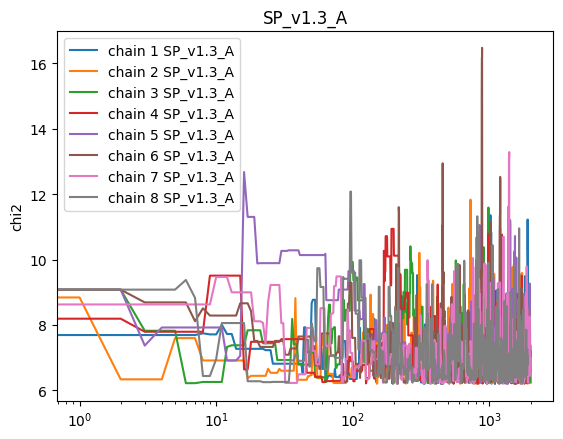

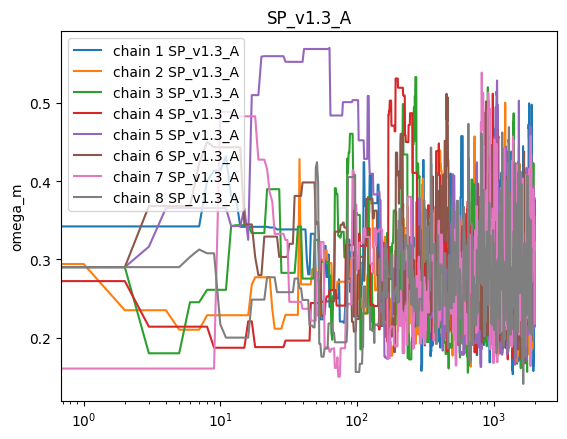

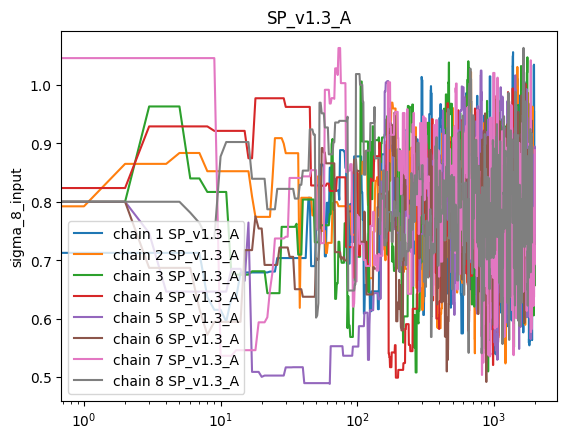

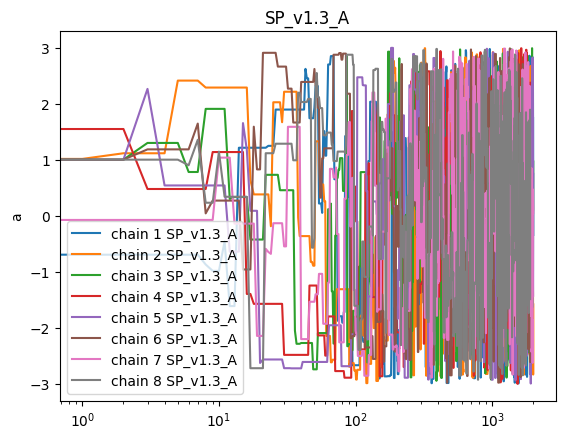

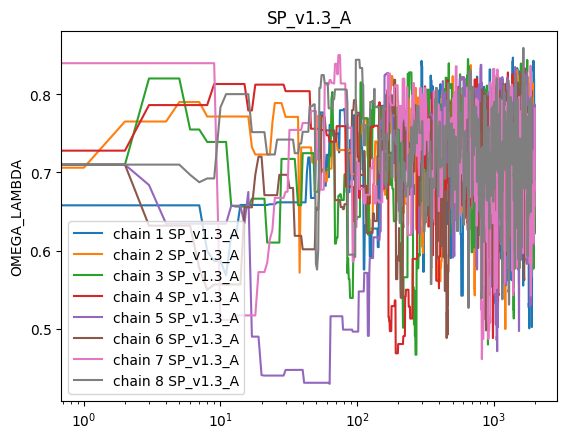

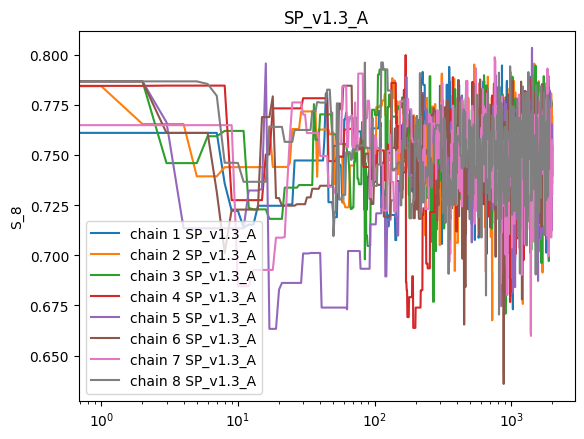

In [8]:
#PLOT CHAIN TRENDS

Nchains = 8
for root in roots:
    params = np.genfromtxt(root_dir + '{}/getdist_{}.paramnames'.format(root,root),dtype='str')
    params = np.insert(params,0, 'chi2')

    for idx,par in enumerate(params):
        for i in range(1,Nchains+1):
            
            chain = np.loadtxt(root_dir + '{}/samples_{}_{}.txt'.format(root,root,i))

            np.savetxt(root_dir + '{}/getdist_{}_{}.txt'.format(root,root,i),  
                np.column_stack((np.ones_like(chain[:, -1]) ,-(chain[:, -1]-chain[:, -2]), chain[:, 0:-2])))
        
            trend = np.loadtxt(root_dir + '{}/getdist_{}_{}.txt'.format(root,root,i),usecols=idx+1)
            plt.plot(trend, label='chain {} {}'.format(i,root))
            plt.xscale('log')
            plt.legend()
            plt.ylabel('%s'%par)
            plt.title('%s'%root)
        plt.show()

In [ ]:
#READ CHAIN

chains=[]

for root in roots:

    chain = g.samples_for_root(root_dir + '{}/getdist_{}'.format(root,root),
                                   settings={'ignore_rows':0.3})
    
    cov = chain.getCov(pars=np.arange(0,len(params)-3))
    np.savetxt(root_dir + '{}/getdist_cov.txt'.format(root),cov)

    print('R-1 of %s = %s' %(root, chain.getGelmanRubin()))
    chains.append(chain)

## Plot the chain

In [ ]:
g.triangle_plot(chains,['omega_m','sigma_8_input','S_8'],
                legend_labels=roots,
                colors=colours,
                line_args=[{'color':colours[i]} for i in range(len(chains))],
                filled=True)

# g.export('corner_plot_comparison.pdf')

### Output bestfit and sigma values

In [ ]:
#########BESTFIT AND SIGMA VALS##########
params = ['omega_m','ln10^10A_s','OMEGA_LAMBDA','SIGMA_8','S_8']
latex_params = [r'$\Omega_m$',r'$\ln(10^{10}A_s)$',r'$\Omega_\Lambda$',r'$\sigma_8$',
               r'$S_8$']
    
chain_options=chains

for chain in chain_options:

    margestats = chain.getMargeStats()
    likestats = chain.getLikeStats()

    for no in range(len(latex_params)):
        param_stats = margestats.parWithName(params[no])
        like_stats = likestats.parWithName(params[no])
        
        a = uncertainties.ufloat(param_stats.mean,((param_stats.mean-param_stats.limits[0].lower)+(param_stats.limits[0].upper-param_stats.mean))/2)
        latex_params[no] += '& $%.4g$ & '%(like_stats.bestfit_sample)
        latex_params[no] += '${:.3uL}$'.format(a)
        
for param in latex_params:
    param += r'\\'
    print(param)   
